In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")


In [4]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [5]:
if "Person ID" in df.columns:
    df.drop(columns=["Person ID"], inplace=True)

df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})

if "Blood Pressure" in df.columns:
    df[["Systolic_BP", "Diastolic_BP"]] = (
        df["Blood Pressure"].astype(str).str.split("/", expand=True).astype(int)
    )
    df.drop(columns=["Blood Pressure"], inplace=True)

X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="mlogloss",
    random_state=42
)


In [9]:
stack_clf = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=4000),
    stack_method="predict_proba",  
    n_jobs=-1
)


In [10]:
stacking_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", stack_clf)
])


In [11]:
stacking_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Sleep Duration',
                                                   'Quality of Sleep',
                                                   'Physical Activity Level',
                                                   'Stress Level', 'Heart Rate',
                                                   'Daily Steps', 'Systolic_BP',
                                                   'Diastolic_BP']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Occupation',
                                                   'BMI Category'])])),
                ('classifier',
                 StackingClassifier(estimat...
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=5,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=200,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=42, ...))],
                                    final_estimator=LogisticRegression(max_iter=4000),
                                    n_jobs=-1, stack_method='predict_proba'))])

In [12]:
y_pred = stacking_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"STACKING ACCURACY: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


STACKING ACCURACY: 94.67%

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.82      0.93      0.88        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.95        75
   macro avg       0.92      0.92      0.91        75
weighted avg       0.95      0.95      0.95        75


Confusion Matrix:
 [[14  0  1]
 [ 0 44  0]
 [ 3  0 13]]


PermutationExplainer explainer: 11it [00:11,  3.70s/it]                        


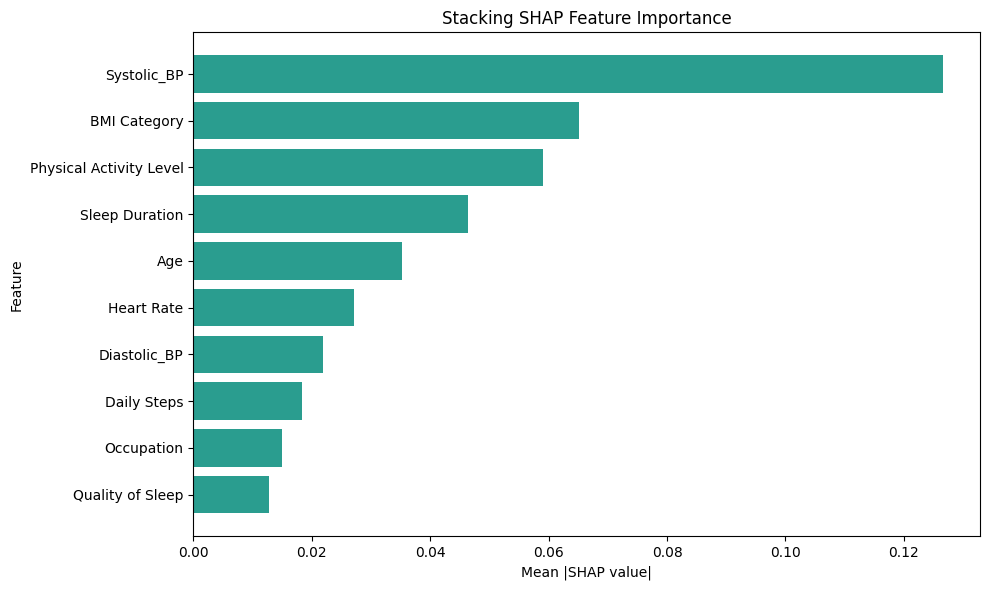

In [13]:
# Requires shap and lime; install from requirements.txt.
import shap

model_label = "Stacking"
explain_model = stacking_model

feature_names = X_train.columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [col for col in feature_names if col not in categorical_cols]

# Encode categorical features so SHAP and LIME can work on the raw input space.
category_maps = {}
encoded_train = X_train.copy()
encoded_test = X_test.copy()

for col in categorical_cols:
    categories = list(pd.Index(X_train[col].astype(str).unique()))
    mapping = {value: idx for idx, value in enumerate(categories)}
    category_maps[col] = mapping
    encoded_train[col] = X_train[col].astype(str).map(mapping).astype(float)
    encoded_test[col] = X_test[col].astype(str).map(mapping).astype(float)


def decode_encoded_frame(encoded_array):
    encoded_array = np.asarray(encoded_array)
    if encoded_array.ndim == 1:
        encoded_array = encoded_array.reshape(1, -1)
    decoded = pd.DataFrame(encoded_array, columns=feature_names)
    for col in categorical_cols:
        inverse_map = {code: label for label, code in category_maps[col].items()}
        codes = pd.to_numeric(decoded[col], errors="coerce").fillna(0).round().astype(int)
        codes = codes.clip(0, len(inverse_map) - 1)
        decoded[col] = codes.map(inverse_map)
    for col in numerical_cols:
        decoded[col] = pd.to_numeric(decoded[col], errors="coerce")
    return decoded


def predict_proba_from_encoded(encoded_array):
    return explain_model.predict_proba(decode_encoded_frame(encoded_array))

encoded_train_array = encoded_train[feature_names].to_numpy(dtype=float)
encoded_test_array = encoded_test[feature_names].to_numpy(dtype=float)

background = shap.sample(encoded_train_array, min(30, len(encoded_train_array)), random_state=42)
sample_rows = encoded_test_array[:min(10, len(encoded_test_array))]

masker = shap.maskers.Independent(background)
shap_explainer = shap.Explainer(
    predict_proba_from_encoded,
    masker,
    feature_names=feature_names,
    algorithm="permutation",
)
shap_values = shap_explainer(sample_rows)

if shap_values.values.ndim == 3:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

top_shap = shap_importance.head(10).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top_shap.index, top_shap.values, color="#2a9d8f")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"{model_label} SHAP Feature Importance")
plt.tight_layout()
plt.show()


Actual label: Insomnia
Predicted label: Insomnia
Prediction probabilities: {'Insomnia': 0.9036, 'None': 0.0593, 'Sleep Apnea': 0.0371}


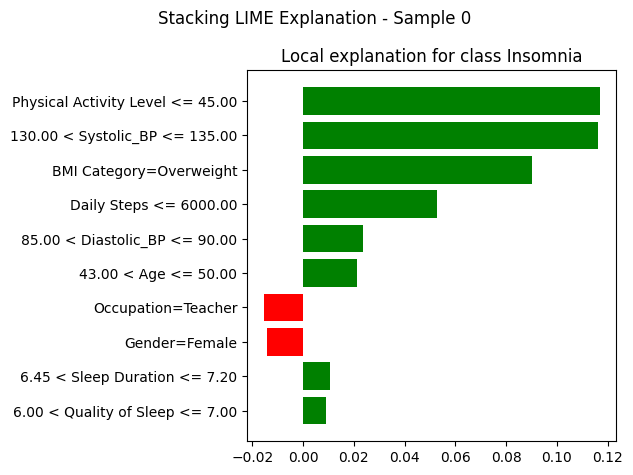

In [14]:
from lime.lime_tabular import LimeTabularExplainer

categorical_feature_indices = [feature_names.index(col) for col in categorical_cols]
categorical_names = {
    feature_names.index(col): list(category_maps[col].keys())
    for col in categorical_cols
}

lime_explainer = LimeTabularExplainer(
    training_data=encoded_train_array,
    feature_names=feature_names,
    class_names=list(le.classes_),
    categorical_features=categorical_feature_indices,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

sample_idx = 0
sample_instance = encoded_test_array[sample_idx]
sample_probs = predict_proba_from_encoded(sample_instance)[0]
sample_pred_idx = int(np.argmax(sample_probs))
sample_pred_label = le.inverse_transform([sample_pred_idx])[0]
sample_true_label = le.inverse_transform([int(np.asarray(y_test)[sample_idx])])[0]

lime_exp = lime_explainer.explain_instance(
    sample_instance,
    predict_proba_from_encoded,
    num_features=min(10, len(feature_names)),
    top_labels=1,
)

print("Actual label:", sample_true_label)
print("Predicted label:", sample_pred_label)
print("Prediction probabilities:", dict(zip(le.classes_, np.round(sample_probs, 4))))

fig = lime_exp.as_pyplot_figure(label=sample_pred_idx)
fig.suptitle(f"{model_label} LIME Explanation - Sample {sample_idx}")
fig.tight_layout()
plt.show()


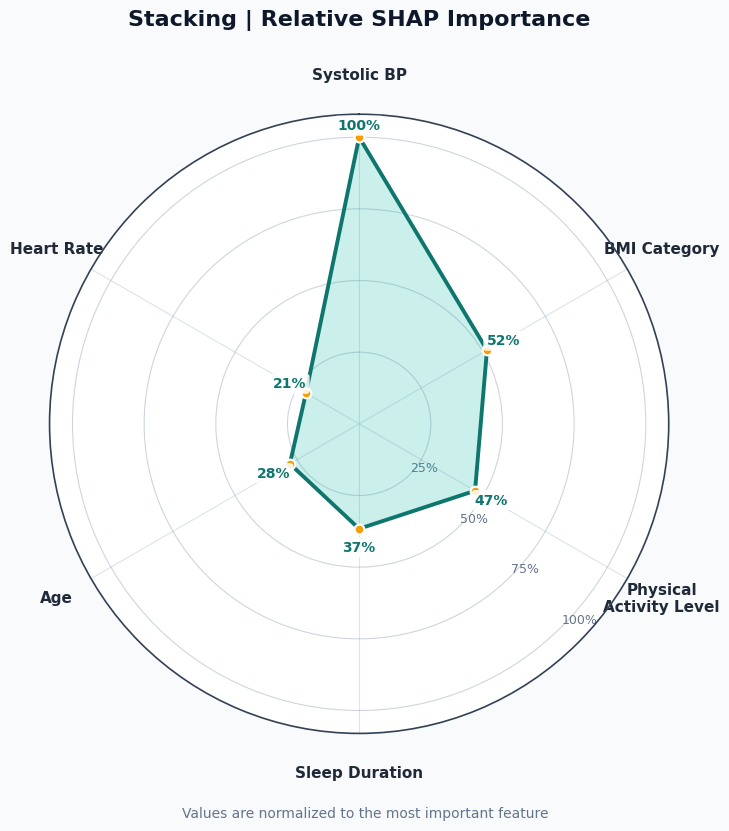

In [15]:
import textwrap

top_n = min(6, len(shap_importance))
radar_importance = shap_importance.head(top_n)
raw_values = radar_importance.to_numpy(dtype=float)
max_value = raw_values.max() if len(raw_values) else 0
radar_values = raw_values / max_value if max_value > 0 else np.zeros_like(raw_values)
radar_values_pct = radar_values * 100

angles = np.linspace(0, 2 * np.pi, top_n, endpoint=False)
closed_angles = np.concatenate([angles, [angles[0]]])
closed_values = np.concatenate([radar_values, [radar_values[0]]])
feature_labels = [textwrap.fill(str(name).replace("_", " "), width=14) for name in radar_importance.index]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
fig.patch.set_facecolor("#f8fafc")
ax.set_facecolor("#ffffff")
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.plot(closed_angles, closed_values, color="#0f766e", linewidth=2.8, marker="o", markersize=7, markerfacecolor="#f59e0b", markeredgecolor="white", markeredgewidth=1.5, zorder=3)
ax.fill(closed_angles, closed_values, color="#14b8a6", alpha=0.22, zorder=2)
ax.set_xticks(angles)
ax.set_xticklabels(feature_labels, fontsize=11, fontweight="semibold", color="#1f2937")
ax.tick_params(axis="x", pad=18)
ax.set_ylim(0, 1.08)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=9, color="#64748b")
ax.set_rlabel_position(135)
ax.yaxis.grid(True, color="#94a3b8", alpha=0.45, linewidth=0.8)
ax.xaxis.grid(True, color="#cbd5e1", alpha=0.65, linewidth=0.8)
ax.spines["polar"].set_color("#334155")
ax.spines["polar"].set_linewidth(1.2)
for angle, value in zip(angles, radar_values_pct):
    ax.text(angle, min(value / 100 + 0.065, 1.04), f"{value:.0f}%", ha="center", va="center", fontsize=10, fontweight="bold", color="#0f766e", bbox={"boxstyle": "round,pad=0.22", "facecolor": "white", "edgecolor": "none", "alpha": 0.85})
ax.set_title(f"{model_label} | Relative SHAP Importance", fontsize=16, fontweight="bold", color="#0f172a", pad=30)
fig.text(0.5, 0.035, "Values are normalized to the most important feature", ha="center", fontsize=10, color="#64748b")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


## PCA visualisation (diagnostic only)

The PCA projection below is used only to inspect class separability in two dimensions. It is **not** included in the stacking classifier pipeline, so the classifier continues to use the complete preprocessed feature set.


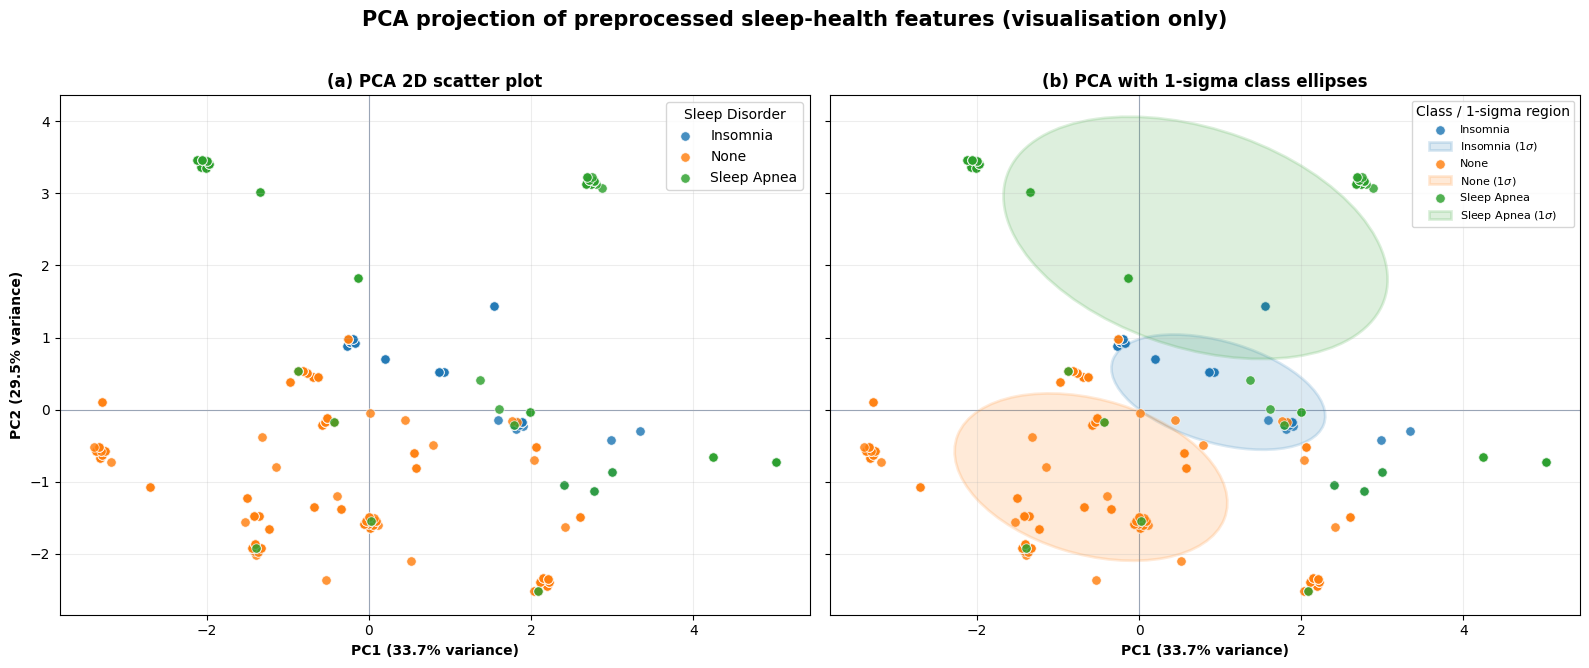

Explained variance — PC1: 33.68%, PC2: 29.47%, total: 63.14%
Note: PCA is not part of the stacking_model pipeline.


In [16]:
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

# This transformer is intentionally separate from `stacking_model`: PCA is for visual diagnosis only.
pca_numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
pca_categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
pca_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), pca_numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), pca_categorical_cols),
    ]
)

X_pca_ready = pca_preprocessor.fit_transform(X)
# PCA expects a dense array; ColumnTransformer may return a sparse matrix after one-hot encoding.
if hasattr(X_pca_ready, "toarray"):
    X_pca_ready = X_pca_ready.toarray()

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_pca_ready)
pca_plot_df = pd.DataFrame(
    principal_components, columns=["PC1", "PC2"]
)
pca_plot_df["Sleep Disorder"] = le.inverse_transform(y_encoded)
explained_variance = pca.explained_variance_ratio_ * 100

def add_one_sigma_ellipse(x_values, y_values, axis, color, label):
    """Add a covariance-based 1-sigma ellipse for one class."""
    if len(x_values) < 2:
        return
    covariance = np.cov(x_values, y_values)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse(
        xy=(np.mean(x_values), np.mean(y_values)),
        width=2 * np.sqrt(max(eigenvalues[0], 0)),
        height=2 * np.sqrt(max(eigenvalues[1], 0)),
        angle=angle, facecolor=color, edgecolor=color, alpha=0.16, linewidth=2, label=label
    )
    axis.add_patch(ellipse)

classes = list(le.classes_)
colors = dict(zip(classes, sns.color_palette("tab10", n_colors=len(classes))))
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)

for class_name in classes:
    class_points = pca_plot_df[pca_plot_df["Sleep Disorder"] == class_name]
    for axis in axes:
        axis.scatter(
            class_points["PC1"], class_points["PC2"],
            s=46, alpha=0.82, color=colors[class_name],
            edgecolor="white", linewidth=0.55, label=class_name
        )
    add_one_sigma_ellipse(
        class_points["PC1"].to_numpy(), class_points["PC2"].to_numpy(),
        axes[1], colors[class_name], f"{class_name} (1$\\sigma$)"
    )

for axis in axes:
    axis.axhline(0, color="#94a3b8", linewidth=0.8, zorder=0)
    axis.axvline(0, color="#94a3b8", linewidth=0.8, zorder=0)
    axis.grid(alpha=0.22)
    axis.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)", fontweight="bold")
axes[0].set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)", fontweight="bold")
axes[0].set_title("(a) PCA 2D scatter plot", fontweight="bold")
axes[1].set_title("(b) PCA with 1-sigma class ellipses", fontweight="bold")
axes[0].legend(title="Sleep Disorder", frameon=True)
axes[1].legend(title="Class / 1-sigma region", frameon=True, fontsize=8)
fig.suptitle("PCA projection of preprocessed sleep-health features (visualisation only)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Explained variance — PC1: {explained_variance[0]:.2f}%, PC2: {explained_variance[1]:.2f}%, total: {explained_variance.sum():.2f}%")
print("Note: PCA is not part of the stacking_model pipeline.")
